### 1. Importing Libraries

In [1]:
import numpy as np 
import pandas as pd

## train_test_split → Splits data into training and testing sets.
from sklearn.model_selection import train_test_split  


## matplotlib & seaborn → Data visualization.
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
# 2. Reading Dataset
df = pd.read_csv('titanic_train.csv',usecols=['Age','Fare','Survived'])

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


### Check Missing Values

In [4]:
df.isnull().mean() * 100  ## Finds percentage of missing values in each column.

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

###  Separate Features and Target

In [7]:
X = df.drop(columns = ['Survived'])
y = df['Survived']

### Train-Test Split

In [8]:
# What it does:

# 80% data → Training
# 20% data → Testing

# random_state=2

# Ensures same split every time.

X_train, X_test, y_train,y_test = train_test_split( X,y,test_size=0.2,random_state = 2)

In [9]:
# View Training Data
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [10]:
## Create Copy of Age Column
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

# Creates a new column:

# Age_imputed

# Purpose:

# Original Age remains untouched.
# Imputation is performed in Age_imputed.

In [11]:
## View Test Data
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [13]:
## Random Sample Imputation
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

## Impute Test Data
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

# What it does:

# Missing values in test data are filled using random ages sampled from the training set.

# This avoids data leakage.

ValueError: cannot set using a list-like indexer with a different length than the value

In [16]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values


array([28.  , 70.5 , 25.  ,  4.  , 30.  , 40.5 ,  4.  , 21.  , 32.5 ,
       62.  , 34.  , 24.  , 24.  ,  7.  , 18.  , 71.  , 34.  , 18.  ,
       22.  , 33.  , 18.  , 45.  , 50.  , 33.  ,  8.  ,  9.  , 35.  ,
       28.  , 24.  , 29.  , 40.  , 35.  , 51.  , 40.5 , 43.  , 24.  ,
       25.  , 61.  , 23.  , 42.  , 29.  ,  9.  , 23.5 , 24.  , 18.  ,
       33.  , 25.  , 27.  , 49.  , 22.  , 19.  , 24.  , 33.  , 21.  ,
       33.  , 20.  , 47.  , 71.  , 25.  ,  1.  , 23.  , 49.  , 27.  ,
       37.  , 45.  , 32.  , 27.  , 50.  , 30.  , 47.  ,  2.  , 18.  ,
       30.  , 28.  , 31.  , 16.  , 21.  , 33.  , 50.  ,  4.  , 24.  ,
       40.  , 16.  , 18.  , 34.5 ,  2.  , 31.  , 58.  , 29.  , 58.  ,
       17.  , 31.  , 17.  ,  0.75, 24.  , 47.  , 28.5 , 20.  , 19.  ,
       25.  , 40.  , 34.  , 45.  ,  7.  , 41.  , 37.  , 20.  , 16.  ,
       21.  , 65.  , 18.  , 16.  , 20.  , 62.  , 20.  , 39.  , 45.5 ,
       41.  , 25.  , 44.  , 41.  , 54.  ,  2.  ,  9.  , 28.  , 18.  ,
       29.  , 28.  ,

In [17]:
X_train['Age'].isnull().sum()

np.int64(148)

In [18]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,36.0
493,71.0,49.5042,71.0
527,NaN,221.7792,33.0


C:\Users\udaya\AppData\Local\Temp\ipykernel_26776\4222035956.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label='Original',hist=False)
C:\Users\udaya\AppData\Local\Temp\ipykernel_26776\4222035956.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[

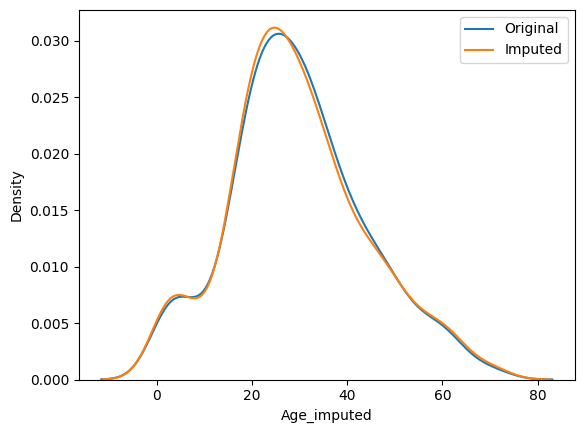

In [30]:
sns.distplot(X_train['Age'],label='Original',hist=False)
sns.distplot(X_train['Age_imputed'],label = 'Imputed',hist=False)

plt.legend()
plt.show()


In [22]:

print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.3495133904614
Variance after random imputation:  210.8813795554211


In [23]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()


,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,67.638824
Age,71.512440,204.349513,204.349513
Age_imputed,67.638824,204.349513,210.881380


<Axes: >

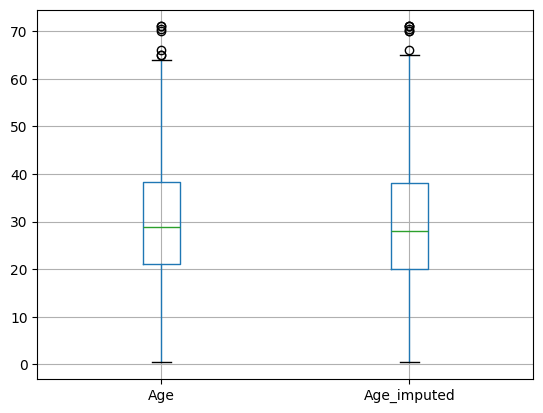

In [26]:
X_train[['Age', 'Age_imputed']].boxplot()

In [32]:
for index, observation in X_train[X_train['Age'].isnull()].iterrows():
    sampled_value = X_train['Age'].dropna().sample(
        1,
        random_state=int(observation['Fare'])
    )

In [34]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])


In [35]:
data.head()


,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [36]:
data.isnull().mean() * 100


FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [37]:

X = data
y = data['SalePrice']

In [38]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)


In [39]:

X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [40]:
X_train.sample(5)


,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
620,NaN,NaN,67000,NaN,NaN
563,Gd,TA,185000,TA,Gd
1388,Gd,TA,377500,TA,Gd
1420,TA,TA,179900,TA,TA
437,NaN,TA,119000,TA,NaN


In [41]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

C:\Users\udaya\AppData\Local\Temp\ipykernel_26776\856878696.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual

In [42]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [43]:
temp

,original,imputed
TA,0.951043,0.952911
Fa,0.037171,0.035959
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [44]:

temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']


temp

,original,imputed
Gd,0.494272,0.645342
TA,0.412439,0.545455
Fa,0.040917,0.051627
Po,0.027823,0.034792
Ex,0.024550,0.033670


C:\Users\udaya\AppData\Local\Temp\ipykernel_26776\2695486330.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
C:\Users\udaya\AppData\Local\Temp\ipykernel_26776\2695486330.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457a

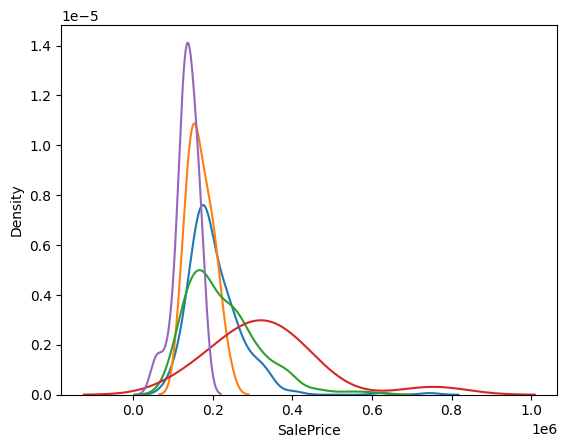

In [45]:

for category in X_train['FireplaceQu'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
plt.show()

C:\Users\udaya\AppData\Local\Temp\ipykernel_26776\3822135228.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
C:\Users\udaya\AppData\Local\Temp\ipykernel_26776\3822135228.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed

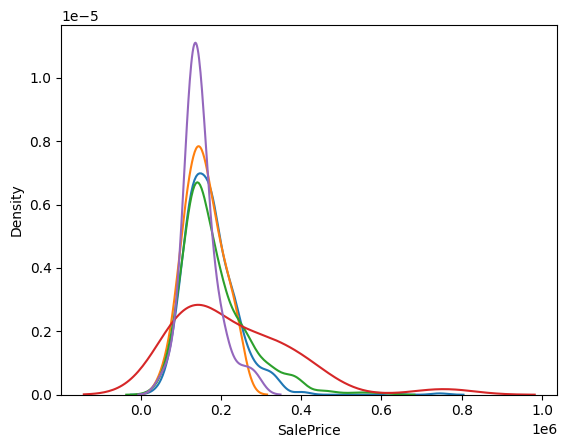

In [46]:

for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
    
plt.show()